# TransMilenio y el 123: qué vimos en el entorno

Este cuaderno cuenta los hallazgos del panel estación–mes (2023 a junio 2026) sin fingir que el delito ocurre *en* el andén.

La pregunta que sí se puede hacer: **el perfil de uso de las estaciones de una UPZ, ¿se parece a la demanda de seguridad de esa misma UPZ?**

## Qué es NUSE (y qué no es)

NUSE es el **Número Único de Seguridad y Emergencias**: las llamadas al **123** que tramita el C4. Cuando alguien reporta un hurto en proceso, una riña o una persona en estado de embriaguez, eso entra aquí.

Tres matices que cambian toda la lectura:

1. **Es demanda de atención, no un fallo judicial.** Más llamados pueden ser más hechos, más teléfonos, o más policía en la zona. No es SIEDCO ni una condena.
2. **Llega por UPZ, no por estación.** Una UPZ es un pedazo de ciudad (más chico que la localidad). Varias estaciones pueden compartir el mismo conteo. Si La Sabana tiene 314 hurtos al mes, eso no significa que CAD o Ricaurte los “produzcan”.
3. **Agrupamos tipos.** En crudo hay decenas de códigos. Aquí hay tres familias: **hurto**, **violencia** (riña, lesiones, disparos…) y **orden público** (embriaguez, ruido, sospechoso…).

Los nombres de UPZ salen del propio NUSE (`UPZ102` = La Sabana, no “la localidad Los Mártires”).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import io

def mostrar(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

BASE = Path(".")
AN = BASE / "salidas_analisis"
IN = BASE / "salidas_integracion"

AZUL, ROJO, VERDE, GRIS = "#1f4e79", "#a03d3d", "#2a7f62", "#6b7280"
plt.rcParams.update({
    "figure.figsize": (8, 4.6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titlepad": 10,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ACENTOS = {
    "El Rincon": "El Rincón", "Los Alcazares": "Los Alcázares",
    "Boyaca Real": "Boyacá Real", "San Cristobal": "San Cristóbal",
    "Antonio Narino": "Antonio Nariño", "Ciudad Bolivar": "Ciudad Bolívar",
    "Usaquen": "Usaquén", "Engativa": "Engativá", "Fontibon": "Fontibón",
    "Los Martires": "Los Mártires",
}

def nom_propio(texto):
    t = str(texto).strip().title()
    for malo, bueno in {"De": "de", "Del": "del", "La": "la", "Las": "las",
                        "Los": "los", "El": "el", "Y": "y"}.items():
        t = t.replace(f" {malo} ", f" {bueno} ")
    t = t[:1].upper() + t[1:] if t else t
    return ACENTOS.get(t, t)

nombres = pd.read_csv(AN / "nombres_upz.csv")
nombres["upz_id"] = nombres["upz_id"].astype(str).str.strip()
nombres["upz_nombre"] = nombres["upz_nombre"].map(nom_propio)

rank = pd.read_csv(AN / "ranking_upz.csv")
rank["upz_id"] = rank["upz_id"].astype(str).str.strip()
rank = rank.merge(nombres, on="upz_id", how="left")
rank["localidad"] = rank["localidad"].map(nom_propio)
rank["etiqueta"] = rank["upz_nombre"].fillna(rank["upz_id"])

upz = pd.read_csv(AN / "panel_upz_mes_agregado.csv")
upz["upz_id"] = upz["upz_id"].astype(str).str.strip()
upz = upz.merge(nombres, on="upz_id", how="left")
upz["etiqueta"] = upz["upz_nombre"].fillna(upz["upz_id"]).map(nom_propio)
upz["localidad"] = upz["localidad"].map(nom_propio)

loc = pd.read_csv(AN / "ranking_localidad.csv")
loc["localidad"] = loc["localidad"].map(nom_propio)

sp = pd.read_csv(AN / "spearman.csv")
est = pd.read_csv(IN / "panel_estacion_mes.csv", usecols=["cod_estacion", "nom_est", "upz_id", "flag_soacha"])
est["upz_id"] = est["upz_id"].astype(str).str.strip()
est["flag_soacha"] = est["flag_soacha"].astype(str).str.lower().isin(("true", "1"))

print(f"UPZ con TransMilenio: {rank['upz_id'].nunique()}  |  estaciones (sin Soacha): {est.loc[~est.flag_soacha, 'cod_estacion'].nunique()}")
print("Ejemplo de nombres:", ", ".join(rank.sort_values("rank_hurto_medio")["etiqueta"].head(5)))

UPZ con TransMilenio: 58  |  estaciones (sin Soacha): 145
Ejemplo de nombres: La Sabana, El Rincón, Las Ferias, Los Alcázares, Chico Lago


## Cómo leer los gráficos

En cada barra o punto, el **nombre es la UPZ** (La Sabana, El Rincón, Chico Lago). Entre paréntesis va la localidad, solo cuando hace falta orientarse.

El periodo es enero 2023 – junio 2026. Sacamos Soacha (no tiene UPZ de Bogotá) y los meses con menos de 20 días de dato.

In [2]:
resumen = pd.DataFrame({
    "pieza": [
        "Estaciones TM (sin Soacha)",
        "UPZ con troncal",
        "Meses por UPZ (típico)",
        "Hurto al 123 / mes, mediana UPZ",
    ],
    "dato": [
        int(est.loc[~est.flag_soacha, "cod_estacion"].nunique()),
        int(rank["upz_id"].nunique()),
        int(rank["n_meses"].median()),
        round(rank["hurto_mensual_medio"].median(), 0),
    ],
})
resumen

,pieza,dato
0,Estaciones TM (sin Soacha),145.0
1,UPZ con troncal,58.0
2,Meses por UPZ (típico),42.0
3,"Hurto al 123 / mes, mediana UPZ",96.0


## 1. El hurto al 123 se concentra en el centro, no en la hora pico

**La Sabana** (Los Mártires) es la UPZ con más hurto reportado: unas **314 llamadas al mes**. Ahí están CAD, Tercer Milenio, Ricaurte, Calle 19, De La Sabana: mucha red, mucha centralidad.

Le siguen **El Rincón** (Suba) y **Las Ferias** (Engativá). No es un ranking de “estaciones inseguras”: es el entorno donde vive esa red.

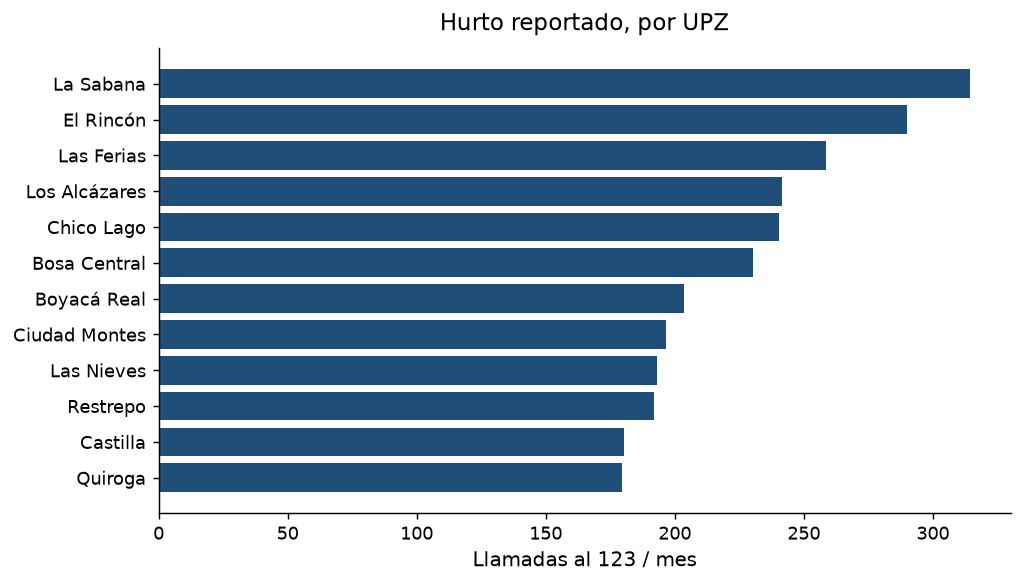

,UPZ,localidad,Estaciones,Hurto / mes,Violencia / mes
0,La Sabana,Los Mártires,8.0,314.0,746.0
1,El Rincón,Suba,2.0,290.0,2202.0
2,Las Ferias,Engativá,3.0,259.0,866.0
3,Los Alcázares,Barrios Unidos,3.0,242.0,606.0
4,Chico Lago,Chapinero,6.0,240.0,487.0
5,Bosa Central,Bosa,1.0,230.0,1708.0
6,Boyacá Real,Engativá,5.0,203.0,871.0
7,Ciudad Montes,Puente Aranda,2.0,197.0,626.0


In [3]:
top = rank.nsmallest(12, "rank_hurto_medio").iloc[::-1]
fig, ax = plt.subplots()
ax.barh(top["etiqueta"], top["hurto_mensual_medio"], color=AZUL)
ax.set_xlabel("Llamadas al 123 / mes")
ax.set_title("Hurto reportado, por UPZ")
fig.tight_layout()
mostrar(fig)

ficha = rank.nsmallest(8, "rank_hurto_medio")[
    ["etiqueta", "localidad", "n_estaciones", "hurto_mensual_medio", "violencia_mensual_media"]
].rename(columns={
    "etiqueta": "UPZ",
    "n_estaciones": "Estaciones",
    "hurto_mensual_medio": "Hurto / mes",
    "violencia_mensual_media": "Violencia / mes",
})
ficha.round(0)

## 2. La violencia cuenta otra historia

Si el hurto mira al centro, la **violencia** (riñas, lesiones) mira a otro lado: **El Rincón** y **Bosa Central** disparan el conteo. La Sabana sigue alta, pero ya no manda.

Eso importa para no mezclar las tres familias en un solo “índice de inseguridad”. El 123 no es un sabor: son varios.

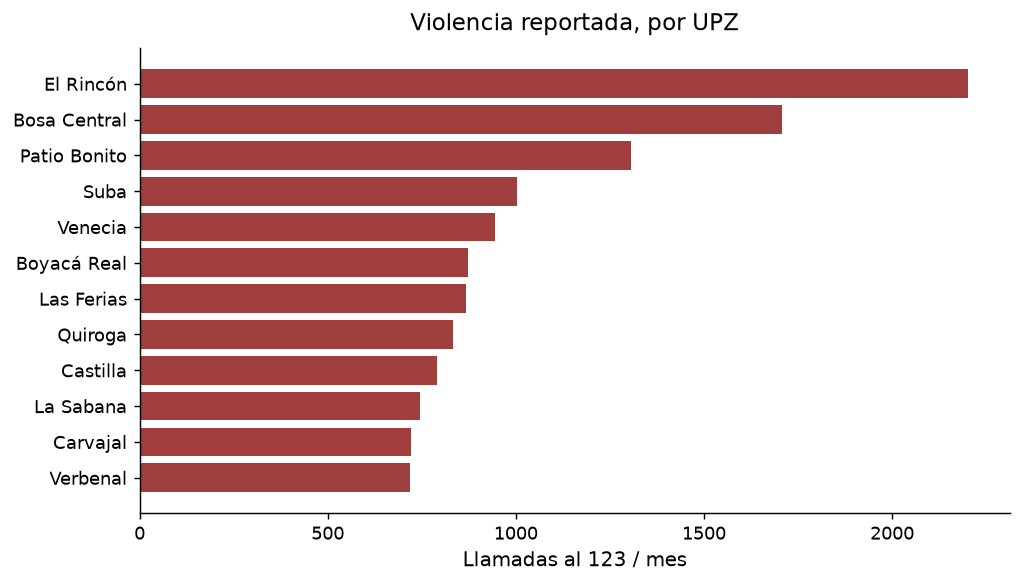

In [4]:
vio = rank.nsmallest(12, "rank_violencia_media").iloc[::-1]
fig, ax = plt.subplots()
ax.barh(vio["etiqueta"], vio["violencia_mensual_media"], color=ROJO)
ax.set_xlabel("Llamadas al 123 / mes")
ax.set_title("Violencia reportada, por UPZ")
fig.tight_layout()
mostrar(fig)


## 3. Más flujo de noche no va con más hurto

La hipótesis tentadora era: *si la estación vive de noche, el entorno pide más 123 por hurto*. En las 58 UPZ **no se sostiene** (Spearman ρ ≈ 0,03).

Chico Lago (Calle 72, Virrey, Calle 100) mueve muchísimo TransMilenio y no lidera el hurto. Bosa Central es más nocturna y sí está arriba, pero es la excepción, no la regla.

El tamaño de cada punto es el flujo de la UPZ. Los nombres son las que más hurto reportan.

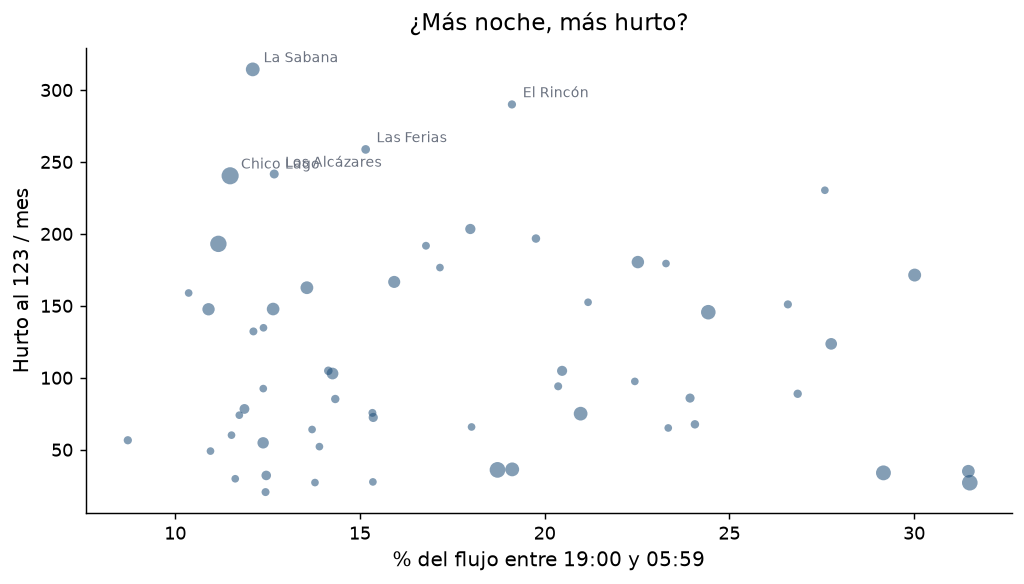

In [5]:
media = rank.copy()
fig, ax = plt.subplots()
tam = np.clip(media["flujo_medio"] / media["flujo_medio"].median() * 22, 18, 90)
ax.scatter(media["pct_nocturno_medio"] * 100, media["hurto_mensual_medio"],
           s=tam, c=AZUL, alpha=0.55, linewidths=0)
for _, r in media.nsmallest(5, "rank_hurto_medio").iterrows():
    ax.annotate(r["etiqueta"], (r["pct_nocturno_medio"] * 100, r["hurto_mensual_medio"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8, color=GRIS)
ax.set_xlabel("% del flujo entre 19:00 y 05:59")
ax.set_ylabel("Hurto al 123 / mes")
ax.set_title("¿Más noche, más hurto?")
fig.tight_layout()
mostrar(fig)


## 4. El fin de semana sí se mueve con la violencia

Cuando cambiamos el desenlace a **violencia**, el corte entre UPZ cambia de figura: más **% de flujo en sábado–domingo–festivo** (ρ ≈ 0,51) y más **% nocturno** (ρ ≈ 0,38) van con más riñas y lesiones reportadas.

Sigue siendo el entorno, no el torniquete. Pero aquí el perfil de uso del TransMilenio sí ordena las UPZ.

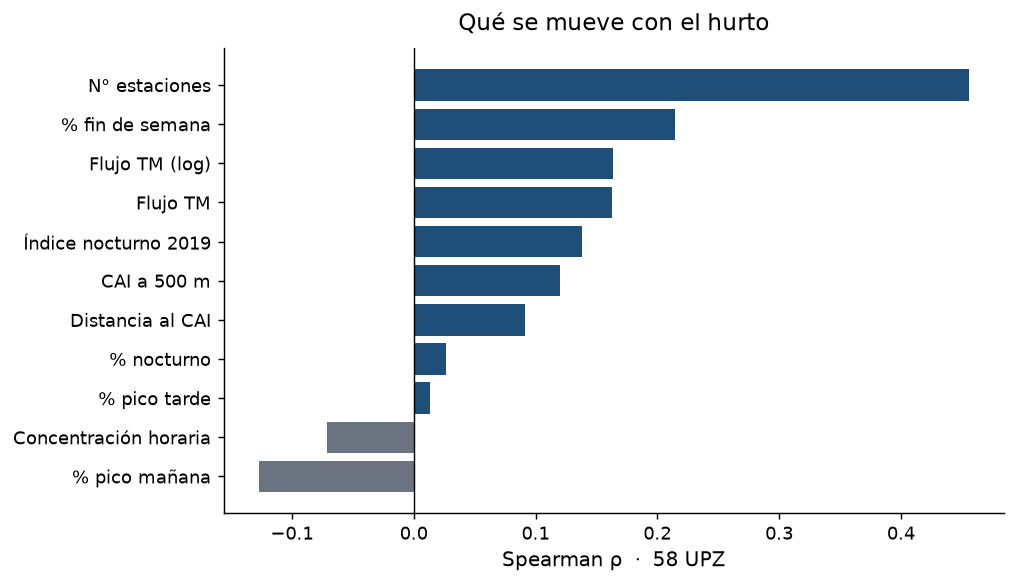

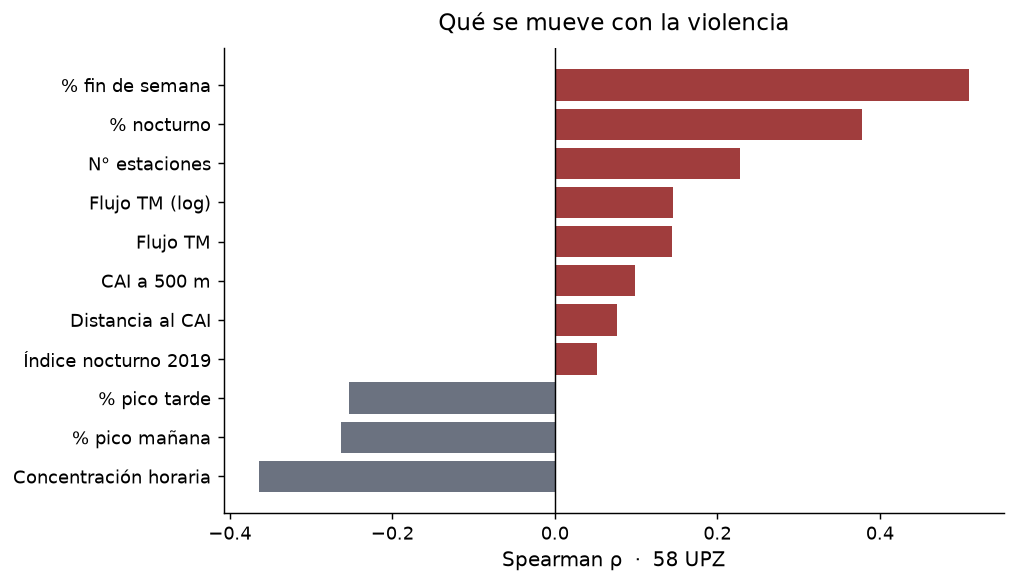

In [6]:
ETIQ = {
    "n_estaciones": "N° estaciones",
    "pct_finde_pond": "% fin de semana",
    "pct_nocturno_pond": "% nocturno",
    "flujo_total_upz": "Flujo TM",
    "log_flujo_upz": "Flujo TM (log)",
    "gini_pond": "Concentración horaria",
    "pct_pico_am_pond": "% pico mañana",
    "pct_pico_pm_pond": "% pico tarde",
    "dist_cai_mediana_m": "Distancia al CAI",
    "n_cai_500m_media": "CAI a 500 m",
    "indice_seguridad_nocturna_2019": "Índice nocturno 2019",
}

def barras_rho(y, titulo, color):
    s = sp.loc[(sp["muestra"] == "media_por_upz") & (sp["y"] == y)].copy()
    s["lab"] = s["x"].map(ETIQ).fillna(s["x"])
    s = s.dropna(subset=["rho"]).sort_values("rho")
    fig, ax = plt.subplots()
    ax.barh(s["lab"], s["rho"], color=np.where(s["rho"] >= 0, color, GRIS))
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Spearman ρ  ·  58 UPZ")
    ax.set_title(titulo)
    fig.tight_layout()
    mostrar(fig)

barras_rho("upz_nuse_hurto", "Qué se mueve con el hurto", AZUL)
barras_rho("upz_nuse_violencia", "Qué se mueve con la violencia", ROJO)

## 5. Más estaciones, más hurto al 123

La única asociación clara con **hurto** en el corte transversal es el **número de estaciones** de la UPZ (ρ ≈ 0,46). La Sabana tiene ocho; Chico Lago, alrededor de siete.

Eso no prueba que el TransMilenio “cause” hurto. Las UPZ con más troncal suelen ser más céntricas, con más gente a pie y más ojos (y más llamadas). Es un indicador de **centralidad urbana**, no de culpa de la estación.

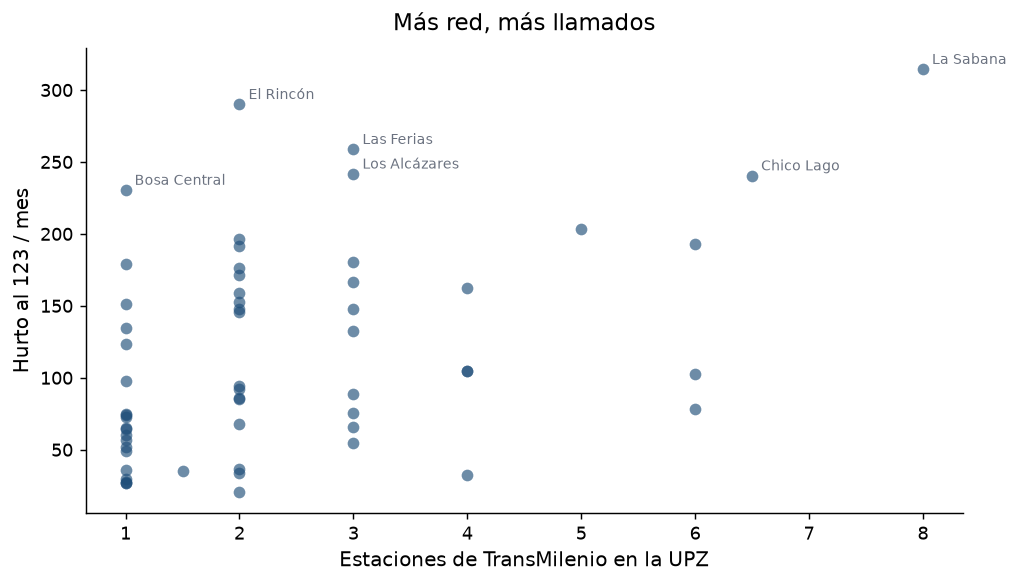

In [7]:
fig, ax = plt.subplots()
ax.scatter(rank["n_estaciones"], rank["hurto_mensual_medio"], c=AZUL, alpha=0.65, s=42, linewidths=0)
for _, r in rank.nsmallest(6, "rank_hurto_medio").iterrows():
    ax.annotate(r["etiqueta"], (r["n_estaciones"], r["hurto_mensual_medio"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8, color=GRIS)
ax.set_xlabel("Estaciones de TransMilenio en la UPZ")
ax.set_ylabel("Hurto al 123 / mes")
ax.set_title("Más red, más llamados")
fig.tight_layout()
mostrar(fig)


## 6. En tasas, Los Mártires sigue primero

Los conteos favorecen UPZ grandes o muy pobladas. La **tasa por 100 mil habitantes** se calcula en la **localidad** (ahí sí hay población). Varias UPZ de Kennedy comparten la misma tasa: no la trates como ranking de UPZ.

**Los Mártires** queda primero (~576 hurtos NUSE por 100 mil hab. al mes). Suba y Bosa, que pesan en conteos de violencia, bajan mucho cuando se divide por población.

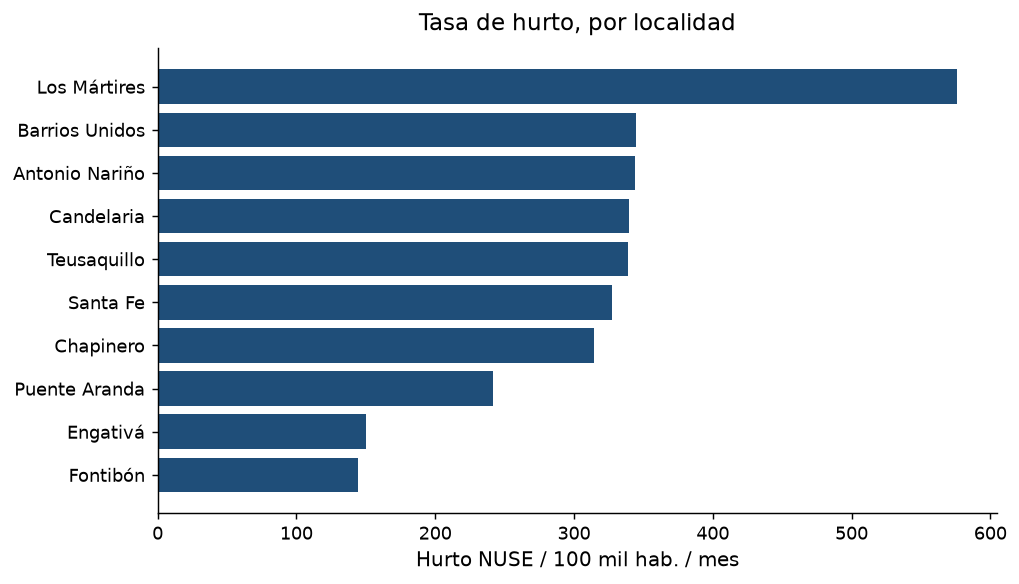

,localidad,tasa_hurto_media,tasa_violencia_media
0,Los Mártires,576.2,1515.3
1,Barrios Unidos,344.8,980.5
2,Antonio Nariño,343.8,1046.9
3,Candelaria,339.9,1396.2
4,Teusaquillo,338.9,789.5
5,Santa Fe,327.6,1171.4
6,Chapinero,314.5,841.6


In [8]:
loc_ord = loc.sort_values("tasa_hurto_media").tail(10)
fig, ax = plt.subplots()
ax.barh(loc_ord["localidad"], loc_ord["tasa_hurto_media"], color=AZUL)
ax.set_xlabel("Hurto NUSE / 100 mil hab. / mes")
ax.set_title("Tasa de hurto, por localidad")
fig.tight_layout()
mostrar(fig)
loc.nsmallest(7, "rank_tasa_hurto")[["localidad", "tasa_hurto_media", "tasa_violencia_media"]].round(1)

## Lo que sí se puede decir (y lo que no)

**Sí**

- El hurto al 123 del entorno de la troncal se concentra en UPZ céntricas como **La Sabana**.
- La violencia dibuja otro mapa: **El Rincón** y **Bosa Central**.
- El perfil nocturno de las estaciones **no ordena** el hurto; el de fin de semana **sí se parece** a la violencia.
- Más estaciones en la UPZ van con más hurto reportado: léase centralidad, no causa.

**No**

- “Esta estación es insegura” o “el TransMilenio genera hurto”.
- Usar el delito de alto impacto (DAI) como si fuera mensual: es anual a localidad.
- Prometer que más CAI o más iluminación bajan el 123 a partir de estas correlaciones.

La ficha útil para el jurado es doble: a la izquierda el **perfil TM de las estaciones**; a la derecha, el **123 de su UPZ**, con nombre propio.